<a href="https://colab.research.google.com/github/Subroy1/MSAI_AllPracticeModules/blob/main/Module%2010/ARIMA_SARIMA_Assignment10_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Required Assignment 10.4: Time Series and Sales

**Expected Time = 60 minutes**

**Total Points = 50**

This activity is meant to extend your work with ARMA models to apply a forecasting model across stores in a retail chain, and items in each store.  You will build models for each store for a specific item and compare this forecast to the model, aggregating all stores.  Also, you will compare a model for sales by store for all items and discuss expected performance for each store according to your forecast.  

In addition to the ARMA models, you will explore an extension of this to include seasonality elements with the SARIMA model.  Both are implemented with `statsmodels`.   

#### Index

- [Problem 1](#-Problem-1)
- [Problem 2](#-Problem-2)
- [Problem 3](#-Problem-3)
- [Problem 4](#-Problem-4)
- [Problem 5](#-Problem-5)
- [Problem 6](#-Problem-6)

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from warnings import filterwarnings
filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import mean_squared_error

### The Data

The data is from a past time series competition on Kaggle [here](https://www.kaggle.com/c/demand-forecasting-kernels-only).  It represents historical sales across 10 stores of 50 items.  Each observation is a day's total sales by store and item.  

In [ ]:
df= pd.read_csv("data/train.csv.zip", compression='zip')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [ ]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


[Back to top](#-Index)

### Problem 1

#### Structuring the data and time series

**5 Points**

To begin, notice that the DataFrame `df` does not have a datetime index.  Below, convert the `date` column to a datetime object and set it as the index to a new DataFrame called `stores_df` below.

In [ ]:
### GRADED
stores_df = ''
# YOUR CODE HERE
stores_df=df.copy()
stores_df['date']=pd.to_datetime(df['date'])
stores_df.set_index(stores_df['date'])

# Answer check
print(stores_df.head())
print('------------\nData Info\n')
print(stores_df.info())

        date  store  item  sales
0 2013-01-01      1     1     13
1 2013-01-02      1     1     11
2 2013-01-03      1     1     14
3 2013-01-04      1     1     13
4 2013-01-05      1     1     10
------------
Data Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB
None


In [ ]:
stores_df.head(2)

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11


[Back to top](#-Index)

### Problem 2

#### Store 1 Model

**10 Points**

In anticipation of building a 30-day forecast for sales of item 1 in store 1, subset the data to only the sales column for item 1 store 1 and assign as a DataFrame to `store_1_item_1` below.

In [ ]:
### GRADED
store_1_item_1 = ''
# YOUR CODE HERE
#store_1_item_1= pd.DataFrame(stores_df[stores_df['store']==1 ]['sales'])
store_1_item_1 = stores_df[ (stores_df['store']==1)  &  (stores_df['item']==1)]['sales']
store_1_item_1= pd.DataFrame(store_1_item_1)

# Answer check
print(store_1_item_1.head())
print(store_1_item_1.shape)

   sales
0     13
1     11
2     14
3     13
4     10
(1826, 1)


[Back to top](#-Index)

### Problem 3

#### Train/Test split

**5 Points**

Now, use the store 1 data from the previous question to create a train-test split where `train_data` is all but the last 30 days of sales data.  You no longer need the store and item columns.  Assign these values as `X_train` and `X_test` respectively.

In [ ]:
### GRADED
X_train, X_test = '', ''
# YOUR CODE HERE
size=len(store_1_item_1)
X_test=store_1_item_1[-30:]
X_train=store_1_item_1[:(size-30)]

# Answer check
print(X_train.tail())
print(X_test.head())


      sales
1791     10
1792     14
1793     28
1794     15
1795     19
      sales
1796     16
1797     31
1798      7
1799     20
1800     17


[Back to top](#-Index)

### Problem 4

#### Assumptions of Linearity

**10 Points**

Next, you will want to check the assumptions of our model before building it.  Specifically, this was the notion that our time series is stationary for the ARMA models.  Use the `adfuller` function to determine if the series is stationary.  Assign the $p$ value to `pval` below.  Consider your threshold at $p = 0.01$.  

In [ ]:
pd.DataFrame(stores_df[stores_df['store'] ==1]['sales']).shape

(91300, 1)

In [ ]:
### GRADED
pval = ''
# YOUR CODE HERE
fullerval=adfuller(pd.DataFrame(X_train))
pval=fullerval[1]

# Answer check
print(f'The p-value is {pval: .4f}')
fullerval # The p-value is  0.0266 hence the series is non stationary .

The p-value is  0.0266


(-3.099625939498419,
 0.02658088302259768,
 23,
 1772,
 {'1%': -3.4340457100503534,
  '5%': -2.8631724504188356,
  '10%': -2.5676390661481077},
 10709.450865297767)

[Back to top](#-Index)

### Problem 5

#### Autocorrelation and Partial Autocorrelation

**10 Points**

Backing up the results of our hypothesis test, the autocorrelation of the original series seems to not be stationary.  Instead, the differenced data and its ACF and PACF plots look better.  We will begin by using these plots to suggest an `order = (1, 0, 1)` model based on the differenced data.  Accordingly, build an `ARIMA` model with `order = (1, 0, 1)` and fit on the training data and assign to `arma` below.

Determine the mean squared error on the test data and assign it as a float to `mse_test` below.  


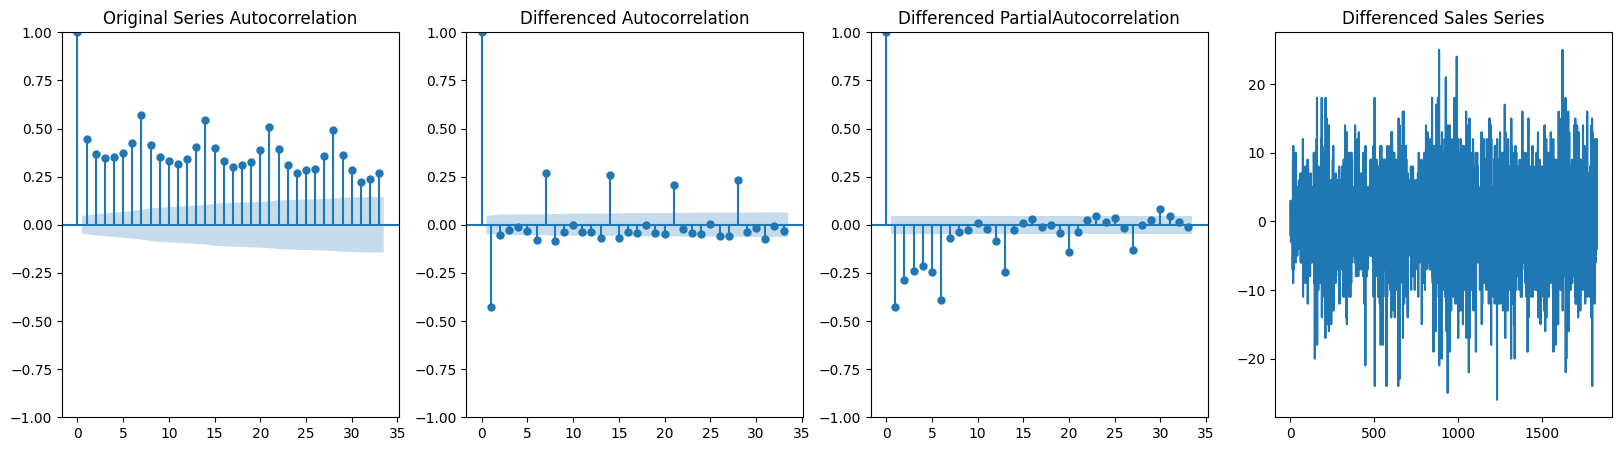

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))
plot_acf(df[(df['store'] == 1) & (df['item'] == 1)]['sales'], ax = ax[0]);
ax[0].set_title('Original Series Autocorrelation')

plot_acf(df[(df['store'] == 1) & (df['item'] == 1)]['sales'].diff().dropna(), ax = ax[1]);
ax[1].set_title('Differenced Autocorrelation')

plot_pacf(df[(df['store'] == 1) & (df['item'] == 1)]['sales'].diff().dropna(), ax = ax[2], method = 'ywm');
ax[2].set_title('Differenced PartialAutocorrelation')

ax[3].plot(df[(df['store'] == 1) & (df['item'] == 1)]['sales'].diff().dropna())
ax[3].set_title('Differenced Sales Series');

# Looking at the differenced PACF and ACF plots , it is an AR and MA model of order 1 . AR(1) and MA(1)

In [ ]:
### GRADED
# YOUR CODE HERE
#The model learns the dynamics of the differenced series
X_train_diff=X_train.diff().dropna()
arma = ARIMA(X_train_diff,order = (1, 0, 1)).fit()

X_test_diff=X_test.diff().dropna()
preds=  arma.forecast(steps=len(X_test_diff))
mse_test= mean_squared_error(X_test_diff,preds)

### ANSWER CHECK
print(preds[:5])
print(mse_test)

1795    2.767694
1796    0.216277
1797    0.022110
1798    0.007334
1799    0.006209
Name: predicted_mean, dtype: float64
64.60187714234881


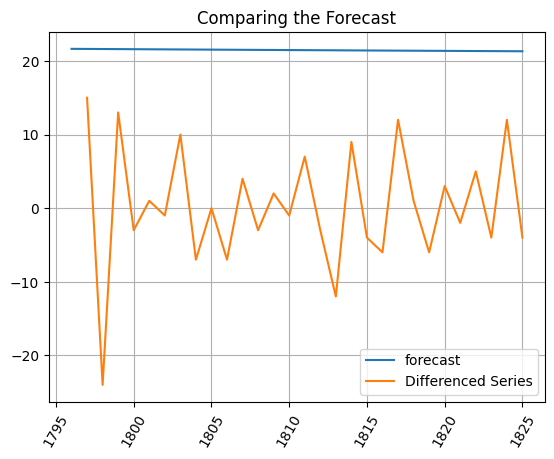

In [ ]:
plt.plot(arma.forecast(steps = len(X_test)), label = 'forecast')
plt.plot(X_test.diff(), label = 'Differenced Series')
plt.title('Comparing the Forecast')
plt.legend();
plt.xticks(rotation = 60)
plt.grid();

[Back to top](#-Index)

### Problem 6

#### A Model with Seasonality

**10 Points**

As discussed with the decomposition models earlier, there are ways to consider a seasonal oscillation within the data.  For ARIMA, a version that adds in a seasonal element is called SARIMA.  In statsmodels, we use the `SARIMAX` estimator to build this model that includes seasonal elements.

Much like the decomposition model, you can have a multiplicative or additive seasonality.  For a multiplicative seasonal effect that we determine is yearly we add an argument

```
seasonal_order=(1, 1, 0, 12)
```

along with the `order = (1, 0, 1)`.  For more information see the user guide from statsmodels [here](https://www.statsmodels.org/dev/examples/notebooks/generated/statespace_sarimax_stata.html).

Below, build a `SARIMAX` estimator with the above order and seasonality and fit on the training data.  Assign the fit model to `sarima` below.

In [ ]:
stores_df.head()

In [ ]:
X_train, X_test = stores_df['sales'].iloc[-700:-30], stores_df.iloc[-30:]

In [ ]:
### GRADED
#NOTE: in your fit statement, use .fit(disp=0)

# YOUR CODE HERE

### ANSWER CHECK
sarima.summary()

In [ ]:
# plt.plot(X_train.index, sarima.predict())
# plt.plot(X_train.index, X_train, alpha = 0.3)
# plt.xticks(rotation = 60)
# plt.title('The SARIMA Model')
# plt.grid();

As you see, the SARIMA model can pick up the seasonal trends we have in this dataset.  You can also get a more sensitive ARMA model by using higher-order terms.  If you are interested in further work here, try grid-searching order and seasonality hyperparameters to determine the best model and order/seasonality parameters.

Also, you can incorporate other features about the data as exogenous elements of both the ARMA and SARIMA models in statsmodels.  Consider trying engineering features with `ts_fresh` and using an exogenous model to see if this improves performance.